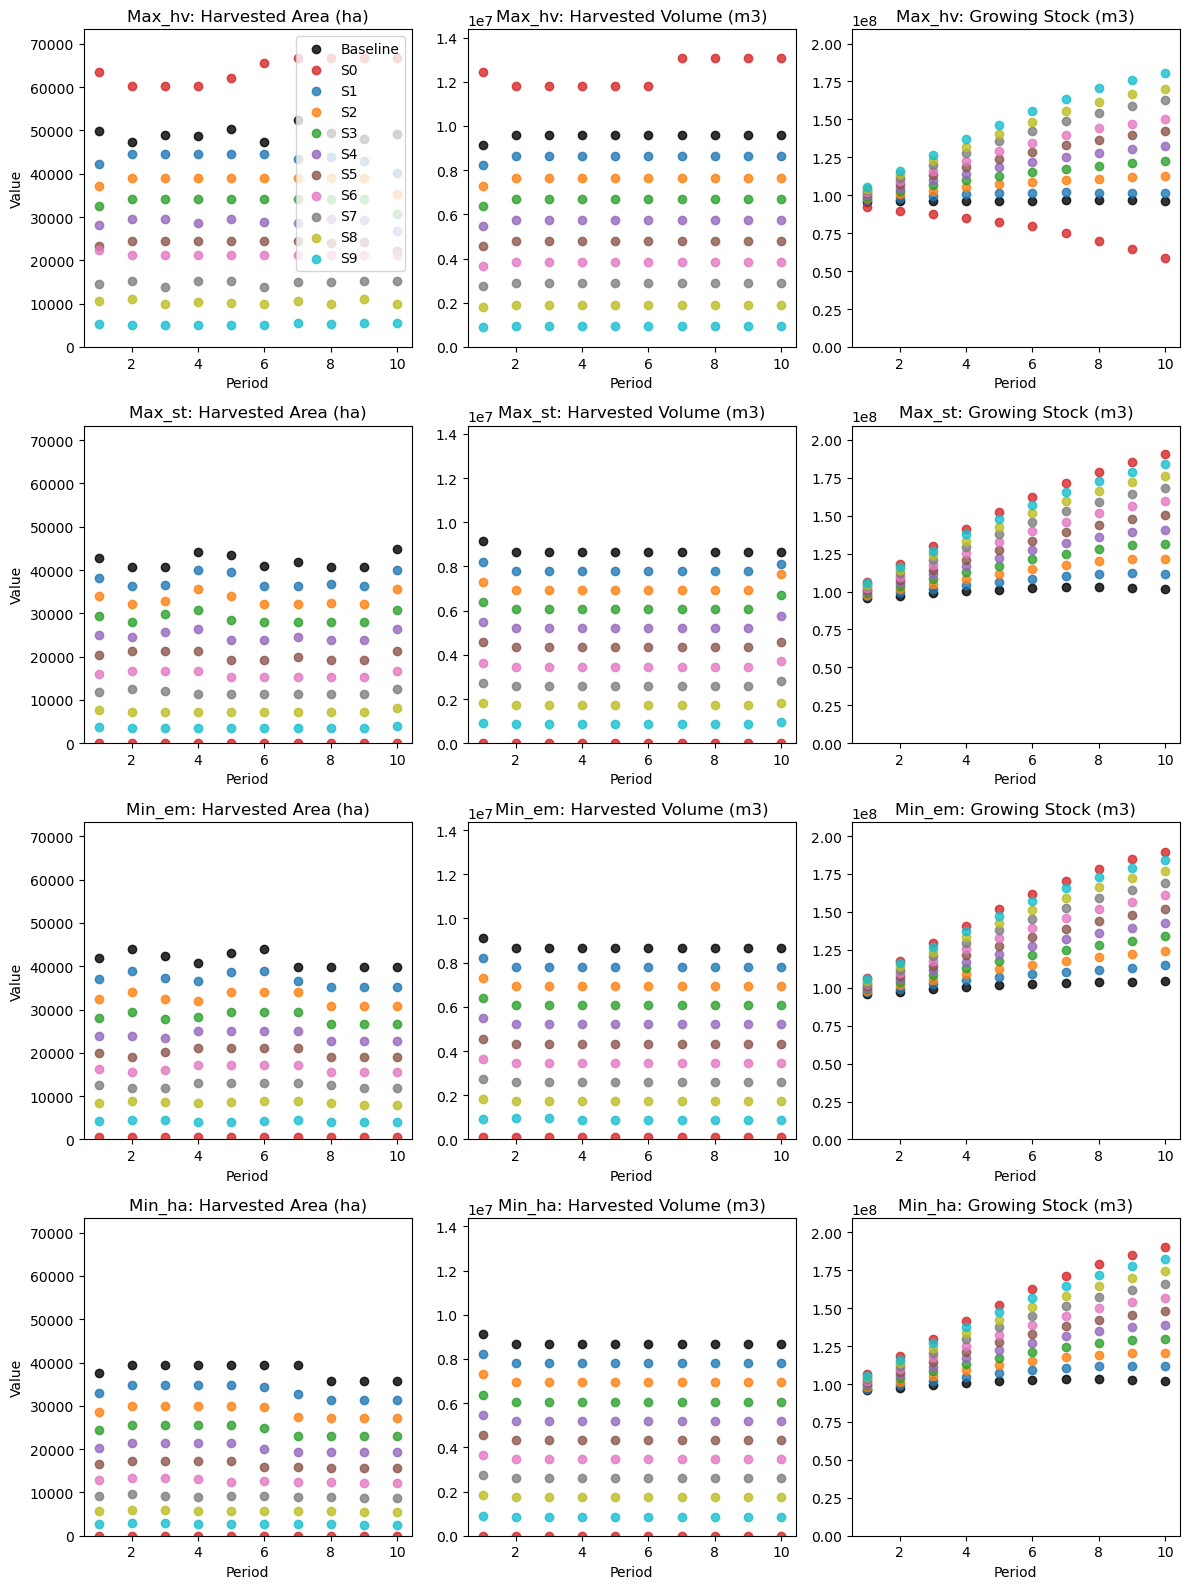

Plot saved to ./plots/fig/equitysilver/equitysilver_combined_scheduling_scatterchart.pdf


In [1]:
#Scatter chart for all scenarios Equity Silver
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_scenarios(csv_files, case_study, obj_mode):
    """
    Plot data from multiple CSV files into a single figure with shared Y-axis ranges for columns as scatter charts.
    
    Parameters:
        csv_files (list of str): List of CSV file paths to read.
        case_study (str): Case study name for output file naming.
        obj_mode (list of str): List of objective modes corresponding to the CSV files.
    """
    # Initialize figure and axes for subplots
    num_obj_modes = len(obj_mode)
    
    # Create a grid of subplots (num_obj_modes subfigures for each objective mode)
    fig, axes = plt.subplots(num_obj_modes, 3, figsize=(12, 4 * num_obj_modes), squeeze=False)

    # Ensure we have the correct shape for the axes (num_obj_modes rows, 3 columns)
    if axes.shape[0] != num_obj_modes:
        axes = axes.reshape(num_obj_modes, 3)

    # Read data for each scenario and plot
    all_oha, all_ohv, all_ogs = [], [], []
    dfs = []

    # Collect data for plotting
    for file in csv_files:
        try:
            df = pd.read_csv(file)
            # Check required columns exist
            if not all(col in df.columns for col in ['oha', 'ohv', 'ogs', 'period']):
                raise ValueError(f"File {file} does not have required columns: ['oha', 'ohv', 'ogs', 'period']")
            dfs.append(df)
            all_oha.extend(df['oha'])
            all_ohv.extend(df['ohv'])
            all_ogs.extend(df['ogs'])
        except Exception as e:
            print(f"Error reading {file}: {e}")
            return

    # Determine common y-axis ranges
    common_ylim_oha = (0, max(all_oha) * 1.1)
    common_ylim_ohv = (0, max(all_ohv) * 1.1)
    common_ylim_ogs = (0, max(all_ogs) * 1.1)

    # Map scenario names to objective modes
    scenario_map = {
        "Max_hv": [
            "equitysilver_max_hv_bau_eqtslvr_compile_scenario.csv",
            "equitysilver_max_hv_evenflow_cons_compile_scenario.csv",
            "equitysilver_max_hv_eqtslvr_AAC_90%_compile_scenario.csv",
            "equitysilver_max_hv_eqtslvr_AAC_80%_compile_scenario.csv",
            "equitysilver_max_hv_eqtslvr_AAC_70%_compile_scenario.csv",
            "equitysilver_max_hv_eqtslvr_AAC_60%_compile_scenario.csv",
            "equitysilver_max_hv_eqtslvr_AAC_50%_compile_scenario.csv",
            "equitysilver_max_hv_eqtslvr_AAC_40%_compile_scenario.csv",
            "equitysilver_max_hv_eqtslvr_AAC_30%_compile_scenario.csv",
            "equitysilver_max_hv_eqtslvr_AAC_20%_compile_scenario.csv",
            "equitysilver_max_hv_eqtslvr_AAC_10%_compile_scenario.csv"
        ],
        "Max_st": [
            "equitysilver_max_st_bau_eqtslvr_compile_scenario_maxstock.csv",
            "equitysilver_max_st_evenflow_cons_compile_scenario_maxstock.csv",
            "equitysilver_max_st_eqtslvr_AAC_90%_compile_scenario_maxstock.csv",
            "equitysilver_max_st_eqtslvr_AAC_80%_compile_scenario_maxstock.csv",
            "equitysilver_max_st_eqtslvr_AAC_70%_compile_scenario_maxstock.csv",
            "equitysilver_max_st_eqtslvr_AAC_60%_compile_scenario_maxstock.csv",
            "equitysilver_max_st_eqtslvr_AAC_50%_compile_scenario_maxstock.csv",
            "equitysilver_max_st_eqtslvr_AAC_40%_compile_scenario_maxstock.csv",
            "equitysilver_max_st_eqtslvr_AAC_30%_compile_scenario_maxstock.csv",
            "equitysilver_max_st_eqtslvr_AAC_20%_compile_scenario_maxstock.csv",
            "equitysilver_max_st_eqtslvr_AAC_10%_compile_scenario_maxstock.csv"
        ],
        "Min_em": [
            "equitysilver_min_em_bau_eqtslvr_compile_scenario_minemission.csv",
            "equitysilver_min_em_evenflow_cons_compile_scenario_minemission.csv",
            "equitysilver_min_em_eqtslvr_AAC_90%_compile_scenario_minemission.csv",
            "equitysilver_min_em_eqtslvr_AAC_80%_compile_scenario_minemission.csv",
            "equitysilver_min_em_eqtslvr_AAC_70%_compile_scenario_minemission.csv",
            "equitysilver_min_em_eqtslvr_AAC_60%_compile_scenario_minemission.csv",
            "equitysilver_min_em_eqtslvr_AAC_50%_compile_scenario_minemission.csv",
            "equitysilver_min_em_eqtslvr_AAC_40%_compile_scenario_minemission.csv",
            "equitysilver_min_em_eqtslvr_AAC_30%_compile_scenario_minemission.csv",
            "equitysilver_min_em_eqtslvr_AAC_20%_compile_scenario_minemission.csv",
            "equitysilver_min_em_eqtslvr_AAC_10%_compile_scenario_minemission.csv"
        ],
        "Min_ha": [
            "equitysilver_min_ha_bau_eqtslvr_compile_scenario.csv",
            "equitysilver_min_ha_evenflow_cons_compile_scenario.csv",
            "equitysilver_min_ha_eqtslvr_AAC_90%_compile_scenario.csv",
            "equitysilver_min_ha_eqtslvr_AAC_80%_compile_scenario.csv",
            "equitysilver_min_ha_eqtslvr_AAC_70%_compile_scenario.csv",
            "equitysilver_min_ha_eqtslvr_AAC_60%_compile_scenario.csv",
            "equitysilver_min_ha_eqtslvr_AAC_50%_compile_scenario.csv",
            "equitysilver_min_ha_eqtslvr_AAC_40%_compile_scenario.csv",
            "equitysilver_min_ha_eqtslvr_AAC_30%_compile_scenario.csv",
            "equitysilver_min_ha_eqtslvr_AAC_20%_compile_scenario.csv",
            "equitysilver_min_ha_eqtslvr_AAC_10%_compile_scenario.csv"
        ]
    }

    
    scenario_short_labels = {
        # Max_hv scenarios
        "./plots/equitysilver/equitysilver_max_hv_bau_eqtslvr_compile_scenario.csv": 'Baseline',
        "./plots/equitysilver/equitysilver_max_hv_evenflow_cons_compile_scenario.csv": 'S0',
        "./plots/equitysilver/equitysilver_max_hv_eqtslvr_AAC_90%_compile_scenario.csv": 'S1',
        "./plots/equitysilver/equitysilver_max_hv_eqtslvr_AAC_80%_compile_scenario.csv": 'S2',
        "./plots/equitysilver/equitysilver_max_hv_eqtslvr_AAC_70%_compile_scenario.csv": 'S3',
        "./plots/equitysilver/equitysilver_max_hv_eqtslvr_AAC_60%_compile_scenario.csv": 'S4',
        "./plots/equitysilver/equitysilver_max_hv_eqtslvr_AAC_50%_compile_scenario.csv": 'S5',
        "./plots/equitysilver/equitysilver_max_hv_eqtslvr_AAC_40%_compile_scenario.csv": 'S6',
        "./plots/equitysilver/equitysilver_max_hv_eqtslvr_AAC_30%_compile_scenario.csv": 'S7',
        "./plots/equitysilver/equitysilver_max_hv_eqtslvr_AAC_20%_compile_scenario.csv": 'S8',
        "./plots/equitysilver/equitysilver_max_hv_eqtslvr_AAC_10%_compile_scenario.csv": 'S9',    
        # Max_st scenarios
        "./plots/equitysilver/equitysilver_max_st_bau_eqtslvr_compile_scenario_maxstock.csv": 'Baseline',
        "./plots/equitysilver/equitysilver_max_st_evenflow_cons_compile_scenario_maxstock.csv": 'S0',
        "./plots/equitysilver/equitysilver_max_st_eqtslvr_AAC_90%_compile_scenario_maxstock.csv": 'S1',
        "./plots/equitysilver/equitysilver_max_st_eqtslvr_AAC_80%_compile_scenario_maxstock.csv": 'S2',
        "./plots/equitysilver/equitysilver_max_st_eqtslvr_AAC_70%_compile_scenario_maxstock.csv": 'S3',
        "./plots/equitysilver/equitysilver_max_st_eqtslvr_AAC_60%_compile_scenario_maxstock.csv": 'S4',
        "./plots/equitysilver/equitysilver_max_st_eqtslvr_AAC_50%_compile_scenario_maxstock.csv": 'S5',
        "./plots/equitysilver/equitysilver_max_st_eqtslvr_AAC_40%_compile_scenario_maxstock.csv": 'S6',
        "./plots/equitysilver/equitysilver_max_st_eqtslvr_AAC_30%_compile_scenario_maxstock.csv": 'S7',
        "./plots/equitysilver/equitysilver_max_st_eqtslvr_AAC_20%_compile_scenario_maxstock.csv": 'S8',
        "./plots/equitysilver/equitysilver_max_st_eqtslvr_AAC_10%_compile_scenario_maxstock.csv": 'S9',    
        # Min_em scenarios
        "./plots/equitysilver/equitysilver_min_em_bau_eqtslvr_compile_scenario_minemission.csv": 'Baseline',
        "./plots/equitysilver/equitysilver_min_em_evenflow_cons_compile_scenario_minemission.csv": 'S0',
        "./plots/equitysilver/equitysilver_min_em_eqtslvr_AAC_90%_compile_scenario_minemission.csv": 'S1',
        "./plots/equitysilver/equitysilver_min_em_eqtslvr_AAC_80%_compile_scenario_minemission.csv": 'S2',
        "./plots/equitysilver/equitysilver_min_em_eqtslvr_AAC_70%_compile_scenario_minemission.csv": 'S3',
        "./plots/equitysilver/equitysilver_min_em_eqtslvr_AAC_60%_compile_scenario_minemission.csv": 'S4',
        "./plots/equitysilver/equitysilver_min_em_eqtslvr_AAC_50%_compile_scenario_minemission.csv": 'S5',
        "./plots/equitysilver/equitysilver_min_em_eqtslvr_AAC_40%_compile_scenario_minemission.csv": 'S6',
        "./plots/equitysilver/equitysilver_min_em_eqtslvr_AAC_30%_compile_scenario_minemission.csv": 'S7',
        "./plots/equitysilver/equitysilver_min_em_eqtslvr_AAC_20%_compile_scenario_minemission.csv": 'S8',
        "./plots/equitysilver/equitysilver_min_em_eqtslvr_AAC_10%_compile_scenario_minemission.csv": 'S9',
        # Min_ha scenarios
        "./plots/equitysilver/equitysilver_min_ha_bau_eqtslvr_compile_scenario.csv": 'Baseline',
        "./plots/equitysilver/equitysilver_min_ha_evenflow_cons_compile_scenario.csv": 'S0',
        "./plots/equitysilver/equitysilver_min_ha_eqtslvr_AAC_90%_compile_scenario.csv": 'S1',
        "./plots/equitysilver/equitysilver_min_ha_eqtslvr_AAC_80%_compile_scenario.csv": 'S2',
        "./plots/equitysilver/equitysilver_min_ha_eqtslvr_AAC_70%_compile_scenario.csv": 'S3',
        "./plots/equitysilver/equitysilver_min_ha_eqtslvr_AAC_60%_compile_scenario.csv": 'S4',
        "./plots/equitysilver/equitysilver_min_ha_eqtslvr_AAC_50%_compile_scenario.csv": 'S5',
        "./plots/equitysilver/equitysilver_min_ha_eqtslvr_AAC_40%_compile_scenario.csv": 'S6',
        "./plots/equitysilver/equitysilver_min_ha_eqtslvr_AAC_30%_compile_scenario.csv": 'S7',
        "./plots/equitysilver/equitysilver_min_ha_eqtslvr_AAC_20%_compile_scenario.csv": 'S8',
        "./plots/equitysilver/equitysilver_min_ha_eqtslvr_AAC_10%_compile_scenario.csv": 'S9',
        }


    color_palette = {
        'Baseline': 'black',
        'S0': mcolors.TABLEAU_COLORS['tab:red'],
        'S1': mcolors.TABLEAU_COLORS['tab:blue'],
        'S2': mcolors.TABLEAU_COLORS['tab:orange'],
        'S3': mcolors.TABLEAU_COLORS['tab:green'],
        'S4': mcolors.TABLEAU_COLORS['tab:purple'],
        'S5': mcolors.TABLEAU_COLORS['tab:brown'],
        'S6': mcolors.TABLEAU_COLORS['tab:pink'],
        'S7': mcolors.TABLEAU_COLORS['tab:gray'],
        'S8': mcolors.TABLEAU_COLORS['tab:olive'],
        'S9': mcolors.TABLEAU_COLORS['tab:cyan']
    }


    # Plot each DataFrame for each objective mode
    for i, obj in enumerate(obj_mode):
        for j, (data, title, ylabel) in enumerate(
            zip(
                ['oha', 'ohv', 'ogs'],
                [f'{obj}: Harvested Area (ha)', f'{obj}: Harvested Volume (m3)', f'{obj}: Growing Stock (m3)'],
                ["Harvested Area (ha)", "Harvested Volume (m3)", "Growing Stock (m3)"]
            )
        ):
            # Filter scenarios for the current objective mode
            filtered_scenarios = scenario_map.get(obj, [])
            for idx, scenario in enumerate(filtered_scenarios):
                # Find the scenario CSV file
                scenario_file = next((file for file in csv_files if scenario in file), None)
                if scenario_file:
                    scenario_data = pd.read_csv(scenario_file)
                    short_label = scenario_short_labels.get(scenario_file, scenario_file)  # Default to full file name if no short label found                 

                    color = color_palette.get(short_label, mcolors.TABLEAU_COLORS['tab:blue'])  # Default color if not found
                    
                    scatter = axes[i, j].scatter(scenario_data['period'], scenario_data[data], label=f'{short_label}', alpha=0.8, color=color)

            # Set the y-axis to the common limit for all columns
            if j == 0:
                axes[i, j].set_ylim(common_ylim_oha)
            elif j == 1:
                axes[i, j].set_ylim(common_ylim_ohv)
            else:
                axes[i, j].set_ylim(common_ylim_ogs)

            axes[i, j].set_title(title)
            axes[i, j].set_xlabel("Period")
            axes[0, 0].legend()

        # Set Y-label only on the first column
        axes[i, 0].set_ylabel("Value")

    # Adjust layout to avoid overlap
    plt.tight_layout()

    # Save the figure
    folder_path = os.path.join('./plots/fig', case_study)
    os.makedirs(folder_path, exist_ok=True)
    file_name = f"{case_study}_combined_scheduling_scatterchart.pdf"
    file_path = os.path.join(folder_path, file_name)
    plt.savefig(file_path, format='pdf')
    plt.show()
    plt.close()
    print(f"Plot saved to {file_path}")

folder_path = './plots/equitysilver'  # Adjust this to the actual folder path
csv_files = [
    os.path.join(folder_path, "equitysilver_max_hv_bau_eqtslvr_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_max_hv_evenflow_cons_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_max_hv_eqtslvr_AAC_10%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_max_hv_eqtslvr_AAC_20%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_max_hv_eqtslvr_AAC_30%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_max_hv_eqtslvr_AAC_40%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_max_hv_eqtslvr_AAC_50%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_max_hv_eqtslvr_AAC_60%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_max_hv_eqtslvr_AAC_70%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_max_hv_eqtslvr_AAC_80%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_max_hv_eqtslvr_AAC_90%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_max_st_bau_eqtslvr_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "equitysilver_max_st_evenflow_cons_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "equitysilver_max_st_eqtslvr_AAC_10%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "equitysilver_max_st_eqtslvr_AAC_20%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "equitysilver_max_st_eqtslvr_AAC_30%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "equitysilver_max_st_eqtslvr_AAC_40%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "equitysilver_max_st_eqtslvr_AAC_50%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "equitysilver_max_st_eqtslvr_AAC_60%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "equitysilver_max_st_eqtslvr_AAC_70%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "equitysilver_max_st_eqtslvr_AAC_80%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "equitysilver_max_st_eqtslvr_AAC_90%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "equitysilver_min_em_bau_eqtslvr_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "equitysilver_min_em_eqtslvr_AAC_10%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "equitysilver_min_em_evenflow_cons_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "equitysilver_min_em_eqtslvr_AAC_20%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "equitysilver_min_em_eqtslvr_AAC_30%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "equitysilver_min_em_eqtslvr_AAC_40%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "equitysilver_min_em_eqtslvr_AAC_50%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "equitysilver_min_em_eqtslvr_AAC_60%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "equitysilver_min_em_eqtslvr_AAC_70%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "equitysilver_min_em_eqtslvr_AAC_80%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "equitysilver_min_em_eqtslvr_AAC_90%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "equitysilver_min_ha_bau_eqtslvr_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_min_ha_evenflow_cons_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_min_ha_eqtslvr_AAC_10%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_min_ha_eqtslvr_AAC_20%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_min_ha_eqtslvr_AAC_30%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_min_ha_eqtslvr_AAC_40%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_min_ha_eqtslvr_AAC_50%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_min_ha_eqtslvr_AAC_60%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_min_ha_eqtslvr_AAC_70%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_min_ha_eqtslvr_AAC_80%_compile_scenario.csv"),
    os.path.join(folder_path, "equitysilver_min_ha_eqtslvr_AAC_90%_compile_scenario.csv"),
]
case_study = 'equitysilver'
obj_mode = ['Max_hv', 'Max_st', 'Min_em', 'Min_ha']


plot_scenarios(csv_files, case_study, obj_mode)


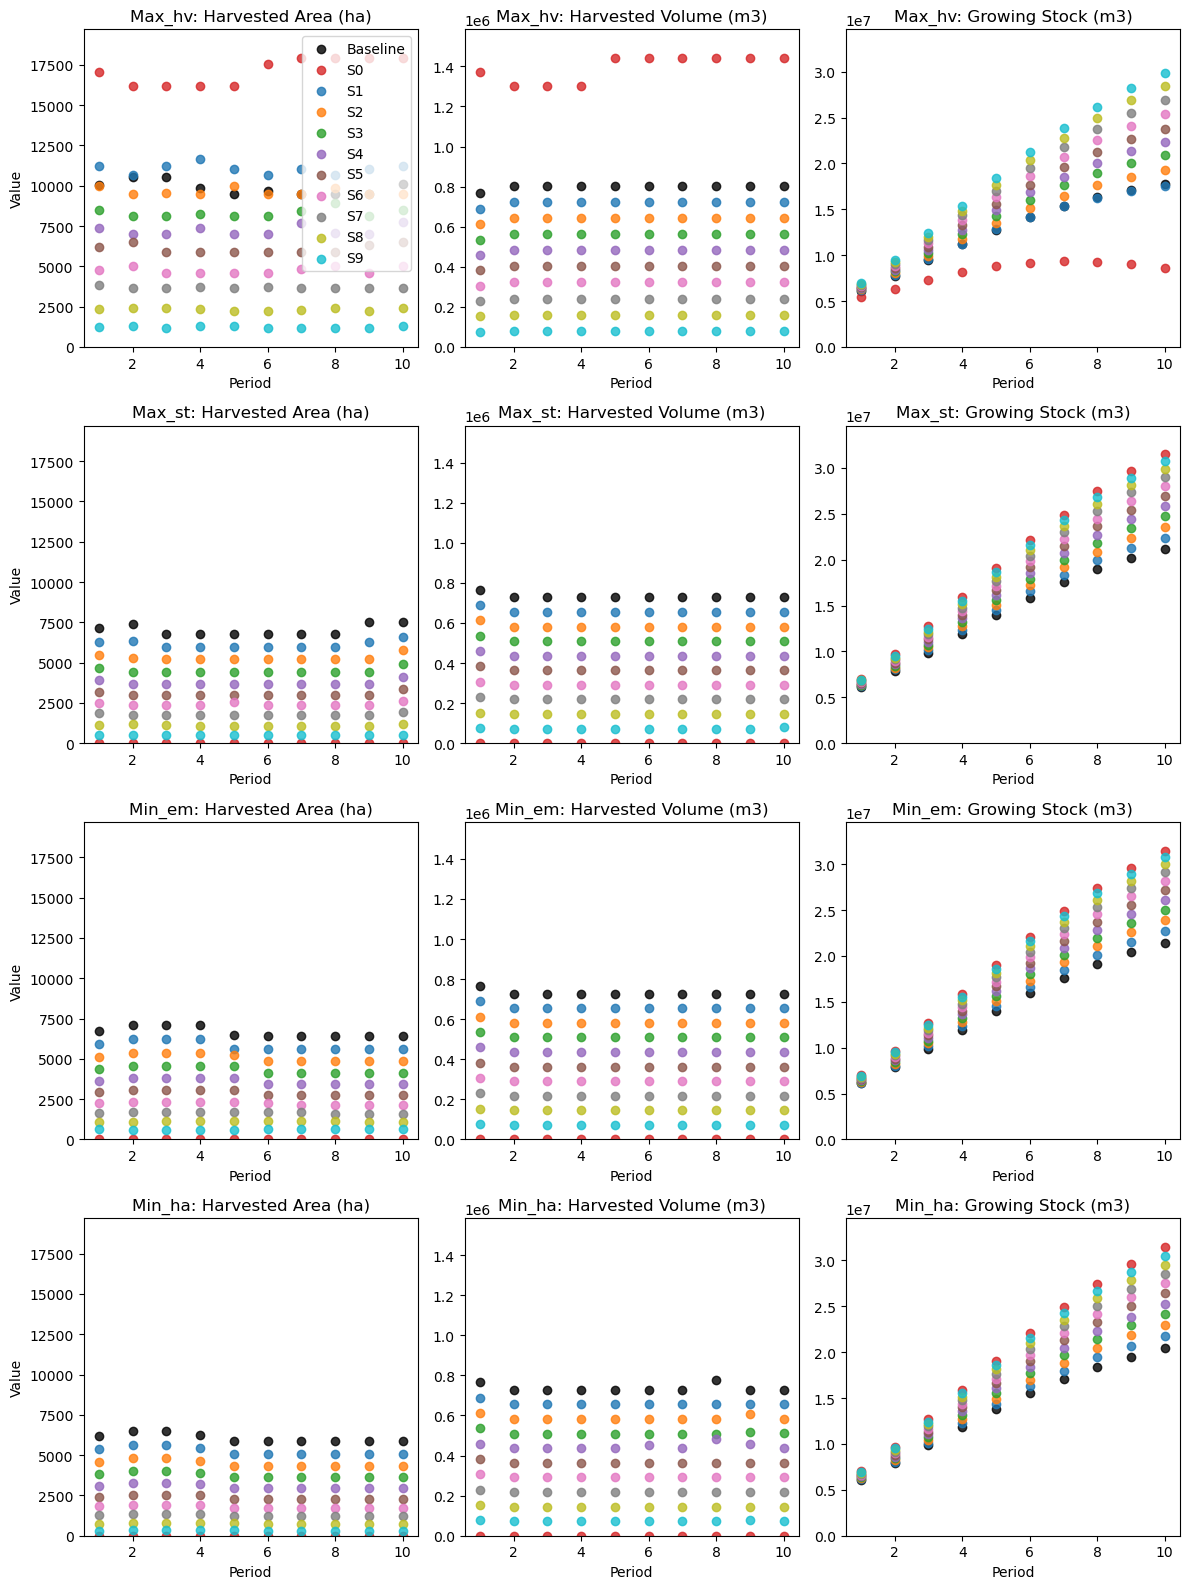

Plot saved to ./plots/fig/goldenbear/goldenbear_combined_scheduling_scatterchart.pdf


In [2]:
#Scatter chart for all scenarios Golden Bear
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_scenarios(csv_files, case_study, obj_mode):
    """
    Plot data from multiple CSV files into a single figure with shared Y-axis ranges for columns as scatter charts.
    
    Parameters:
        csv_files (list of str): List of CSV file paths to read.
        case_study (str): Case study name for output file naming.
        obj_mode (list of str): List of objective modes corresponding to the CSV files.
    """
    # Initialize figure and axes for subplots
    num_obj_modes = len(obj_mode)
    
    # Create a grid of subplots (num_obj_modes subfigures for each objective mode)
    fig, axes = plt.subplots(num_obj_modes, 3, figsize=(12, 4 * num_obj_modes), squeeze=False)

    # Ensure we have the correct shape for the axes (num_obj_modes rows, 3 columns)
    if axes.shape[0] != num_obj_modes:
        axes = axes.reshape(num_obj_modes, 3)

    # Read data for each scenario and plot
    all_oha, all_ohv, all_ogs = [], [], []
    dfs = []

    # Collect data for plotting
    for file in csv_files:
        try:
            df = pd.read_csv(file)
            # Check required columns exist
            if not all(col in df.columns for col in ['oha', 'ohv', 'ogs', 'period']):
                raise ValueError(f"File {file} does not have required columns: ['oha', 'ohv', 'ogs', 'period']")
            dfs.append(df)
            all_oha.extend(df['oha'])
            all_ohv.extend(df['ohv'])
            all_ogs.extend(df['ogs'])
        except Exception as e:
            print(f"Error reading {file}: {e}")
            return

    # Determine common y-axis ranges
    common_ylim_oha = (0, max(all_oha) * 1.1)
    common_ylim_ohv = (0, max(all_ohv) * 1.1)
    common_ylim_ogs = (0, max(all_ogs) * 1.1)

    # Map scenario names to objective modes
    scenario_map = {
        "Max_hv": [
            "goldenbear_max_hv_bau_gldbr_compile_scenario.csv",
            "goldenbear_max_hv_evenflow_cons_compile_scenario.csv",
            "goldenbear_max_hv_gldbr_AAC_90%_compile_scenario.csv",
            "goldenbear_max_hv_gldbr_AAC_80%_compile_scenario.csv",
            "goldenbear_max_hv_gldbr_AAC_70%_compile_scenario.csv",
            "goldenbear_max_hv_gldbr_AAC_60%_compile_scenario.csv",
            "goldenbear_max_hv_gldbr_AAC_50%_compile_scenario.csv",
            "goldenbear_max_hv_gldbr_AAC_40%_compile_scenario.csv",
            "goldenbear_max_hv_gldbr_AAC_30%_compile_scenario.csv",
            "goldenbear_max_hv_gldbr_AAC_20%_compile_scenario.csv",
            "goldenbear_max_hv_gldbr_AAC_10%_compile_scenario.csv"
        ],
        "Max_st": [
            "goldenbear_max_st_bau_gldbr_compile_scenario_maxstock.csv",
            "goldenbear_max_st_evenflow_cons_compile_scenario_maxstock.csv",
            "goldenbear_max_st_gldbr_AAC_90%_compile_scenario_maxstock.csv",
            "goldenbear_max_st_gldbr_AAC_80%_compile_scenario_maxstock.csv",
            "goldenbear_max_st_gldbr_AAC_70%_compile_scenario_maxstock.csv",
            "goldenbear_max_st_gldbr_AAC_60%_compile_scenario_maxstock.csv",
            "goldenbear_max_st_gldbr_AAC_50%_compile_scenario_maxstock.csv",
            "goldenbear_max_st_gldbr_AAC_40%_compile_scenario_maxstock.csv",
            "goldenbear_max_st_gldbr_AAC_30%_compile_scenario_maxstock.csv",
            "goldenbear_max_st_gldbr_AAC_20%_compile_scenario_maxstock.csv",
            "goldenbear_max_st_gldbr_AAC_10%_compile_scenario_maxstock.csv"
        ],
        "Min_em": [
            "goldenbear_min_em_bau_gldbr_compile_scenario_minemission.csv",
            "goldenbear_min_em_evenflow_cons_compile_scenario_minemission.csv",
            "goldenbear_min_em_gldbr_AAC_90%_compile_scenario_minemission.csv",
            "goldenbear_min_em_gldbr_AAC_80%_compile_scenario_minemission.csv",
            "goldenbear_min_em_gldbr_AAC_70%_compile_scenario_minemission.csv",
            "goldenbear_min_em_gldbr_AAC_60%_compile_scenario_minemission.csv",
            "goldenbear_min_em_gldbr_AAC_50%_compile_scenario_minemission.csv",
            "goldenbear_min_em_gldbr_AAC_40%_compile_scenario_minemission.csv",
            "goldenbear_min_em_gldbr_AAC_30%_compile_scenario_minemission.csv",
            "goldenbear_min_em_gldbr_AAC_20%_compile_scenario_minemission.csv",
            "goldenbear_min_em_gldbr_AAC_10%_compile_scenario_minemission.csv"
        ],
        "Min_ha": [
            "goldenbear_min_ha_bau_gldbr_compile_scenario.csv",
            "goldenbear_min_ha_evenflow_cons_compile_scenario.csv",
            "goldenbear_min_ha_gldbr_AAC_90%_compile_scenario.csv",
            "goldenbear_min_ha_gldbr_AAC_80%_compile_scenario.csv",
            "goldenbear_min_ha_gldbr_AAC_70%_compile_scenario.csv",
            "goldenbear_min_ha_gldbr_AAC_60%_compile_scenario.csv",
            "goldenbear_min_ha_gldbr_AAC_50%_compile_scenario.csv",
            "goldenbear_min_ha_gldbr_AAC_40%_compile_scenario.csv",
            "goldenbear_min_ha_gldbr_AAC_30%_compile_scenario.csv",
            "goldenbear_min_ha_gldbr_AAC_20%_compile_scenario.csv",
            "goldenbear_min_ha_gldbr_AAC_10%_compile_scenario.csv"
        ]
    }

    
    scenario_short_labels = {
        # Max_hv scenarios
        "./plots/goldenbear/goldenbear_max_hv_bau_gldbr_compile_scenario.csv": 'Baseline',
        "./plots/goldenbear/goldenbear_max_hv_evenflow_cons_compile_scenario.csv": 'S0',
        "./plots/goldenbear/goldenbear_max_hv_gldbr_AAC_90%_compile_scenario.csv": 'S1',
        "./plots/goldenbear/goldenbear_max_hv_gldbr_AAC_80%_compile_scenario.csv": 'S2',
        "./plots/goldenbear/goldenbear_max_hv_gldbr_AAC_70%_compile_scenario.csv": 'S3',
        "./plots/goldenbear/goldenbear_max_hv_gldbr_AAC_60%_compile_scenario.csv": 'S4',
        "./plots/goldenbear/goldenbear_max_hv_gldbr_AAC_50%_compile_scenario.csv": 'S5',
        "./plots/goldenbear/goldenbear_max_hv_gldbr_AAC_40%_compile_scenario.csv": 'S6',
        "./plots/goldenbear/goldenbear_max_hv_gldbr_AAC_30%_compile_scenario.csv": 'S7',
        "./plots/goldenbear/goldenbear_max_hv_gldbr_AAC_20%_compile_scenario.csv": 'S8',
        "./plots/goldenbear/goldenbear_max_hv_gldbr_AAC_10%_compile_scenario.csv": 'S9',    
        # Max_st scenarios
        "./plots/goldenbear/goldenbear_max_st_bau_gldbr_compile_scenario_maxstock.csv": 'Baseline',
        "./plots/goldenbear/goldenbear_max_st_evenflow_cons_compile_scenario_maxstock.csv": 'S0',
        "./plots/goldenbear/goldenbear_max_st_gldbr_AAC_90%_compile_scenario_maxstock.csv": 'S1',
        "./plots/goldenbear/goldenbear_max_st_gldbr_AAC_80%_compile_scenario_maxstock.csv": 'S2',
        "./plots/goldenbear/goldenbear_max_st_gldbr_AAC_70%_compile_scenario_maxstock.csv": 'S3',
        "./plots/goldenbear/goldenbear_max_st_gldbr_AAC_60%_compile_scenario_maxstock.csv": 'S4',
        "./plots/goldenbear/goldenbear_max_st_gldbr_AAC_50%_compile_scenario_maxstock.csv": 'S5',
        "./plots/goldenbear/goldenbear_max_st_gldbr_AAC_40%_compile_scenario_maxstock.csv": 'S6',
        "./plots/goldenbear/goldenbear_max_st_gldbr_AAC_30%_compile_scenario_maxstock.csv": 'S7',
        "./plots/goldenbear/goldenbear_max_st_gldbr_AAC_20%_compile_scenario_maxstock.csv": 'S8',
        "./plots/goldenbear/goldenbear_max_st_gldbr_AAC_10%_compile_scenario_maxstock.csv": 'S9',    
        # Min_em scenarios
        "./plots/goldenbear/goldenbear_min_em_bau_gldbr_compile_scenario_minemission.csv": 'Baseline',
        "./plots/goldenbear/goldenbear_min_em_evenflow_cons_compile_scenario_minemission.csv": 'S0',
        "./plots/goldenbear/goldenbear_min_em_gldbr_AAC_90%_compile_scenario_minemission.csv": 'S1',
        "./plots/goldenbear/goldenbear_min_em_gldbr_AAC_80%_compile_scenario_minemission.csv": 'S2',
        "./plots/goldenbear/goldenbear_min_em_gldbr_AAC_70%_compile_scenario_minemission.csv": 'S3',
        "./plots/goldenbear/goldenbear_min_em_gldbr_AAC_60%_compile_scenario_minemission.csv": 'S4',
        "./plots/goldenbear/goldenbear_min_em_gldbr_AAC_50%_compile_scenario_minemission.csv": 'S5',
        "./plots/goldenbear/goldenbear_min_em_gldbr_AAC_40%_compile_scenario_minemission.csv": 'S6',
        "./plots/goldenbear/goldenbear_min_em_gldbr_AAC_30%_compile_scenario_minemission.csv": 'S7',
        "./plots/goldenbear/goldenbear_min_em_gldbr_AAC_20%_compile_scenario_minemission.csv": 'S8',
        "./plots/goldenbear/goldenbear_min_em_gldbr_AAC_10%_compile_scenario_minemission.csv": 'S9',
        # Min_ha scenarios
        "./plots/goldenbear/goldenbear_min_ha_bau_gldbr_compile_scenario.csv": 'Baseline',
        "./plots/goldenbear/goldenbear_min_ha_evenflow_cons_compile_scenario.csv": 'S0',
        "./plots/goldenbear/goldenbear_min_ha_gldbr_AAC_90%_compile_scenario.csv": 'S1',
        "./plots/goldenbear/goldenbear_min_ha_gldbr_AAC_80%_compile_scenario.csv": 'S2',
        "./plots/goldenbear/goldenbear_min_ha_gldbr_AAC_70%_compile_scenario.csv": 'S3',
        "./plots/goldenbear/goldenbear_min_ha_gldbr_AAC_60%_compile_scenario.csv": 'S4',
        "./plots/goldenbear/goldenbear_min_ha_gldbr_AAC_50%_compile_scenario.csv": 'S5',
        "./plots/goldenbear/goldenbear_min_ha_gldbr_AAC_40%_compile_scenario.csv": 'S6',
        "./plots/goldenbear/goldenbear_min_ha_gldbr_AAC_30%_compile_scenario.csv": 'S7',
        "./plots/goldenbear/goldenbear_min_ha_gldbr_AAC_20%_compile_scenario.csv": 'S8',
        "./plots/goldenbear/goldenbear_min_ha_gldbr_AAC_10%_compile_scenario.csv": 'S9',
        }


    color_palette = {
        'Baseline': 'black',
        'S0': mcolors.TABLEAU_COLORS['tab:red'],
        'S1': mcolors.TABLEAU_COLORS['tab:blue'],
        'S2': mcolors.TABLEAU_COLORS['tab:orange'],
        'S3': mcolors.TABLEAU_COLORS['tab:green'],
        'S4': mcolors.TABLEAU_COLORS['tab:purple'],
        'S5': mcolors.TABLEAU_COLORS['tab:brown'],
        'S6': mcolors.TABLEAU_COLORS['tab:pink'],
        'S7': mcolors.TABLEAU_COLORS['tab:gray'],
        'S8': mcolors.TABLEAU_COLORS['tab:olive'],
        'S9': mcolors.TABLEAU_COLORS['tab:cyan']
    }


    # Plot each DataFrame for each objective mode
    for i, obj in enumerate(obj_mode):
        for j, (data, title, ylabel) in enumerate(
            zip(
                ['oha', 'ohv', 'ogs'],
                [f'{obj}: Harvested Area (ha)', f'{obj}: Harvested Volume (m3)', f'{obj}: Growing Stock (m3)'],
                ["Harvested Area (ha)", "Harvested Volume (m3)", "Growing Stock (m3)"]
            )
        ):
            # Filter scenarios for the current objective mode
            filtered_scenarios = scenario_map.get(obj, [])
            for idx, scenario in enumerate(filtered_scenarios):
                # Find the scenario CSV file
                scenario_file = next((file for file in csv_files if scenario in file), None)
                if scenario_file:
                    scenario_data = pd.read_csv(scenario_file)
                    short_label = scenario_short_labels.get(scenario_file, scenario_file)  # Default to full file name if no short label found                 

                    color = color_palette.get(short_label, mcolors.TABLEAU_COLORS['tab:blue'])  # Default color if not found
                    
                    scatter = axes[i, j].scatter(scenario_data['period'], scenario_data[data], label=f'{short_label}', alpha=0.8, color=color)

            # Set the y-axis to the common limit for all columns
            if j == 0:
                axes[i, j].set_ylim(common_ylim_oha)
            elif j == 1:
                axes[i, j].set_ylim(common_ylim_ohv)
            else:
                axes[i, j].set_ylim(common_ylim_ogs)

            axes[i, j].set_title(title)
            axes[i, j].set_xlabel("Period")
            axes[0, 0].legend()

        # Set Y-label only on the first column
        axes[i, 0].set_ylabel("Value")

    # Adjust layout to avoid overlap
    plt.tight_layout()

    # Save the figure
    folder_path = os.path.join('./plots/fig', case_study)
    os.makedirs(folder_path, exist_ok=True)
    file_name = f"{case_study}_combined_scheduling_scatterchart.pdf"
    file_path = os.path.join(folder_path, file_name)
    plt.savefig(file_path, format='pdf')
    plt.show()
    plt.close()
    print(f"Plot saved to {file_path}")

folder_path = './plots/goldenbear'  # Adjust this to the actual folder path
csv_files = [
    os.path.join(folder_path, "goldenbear_max_hv_bau_gldbr_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_max_hv_evenflow_cons_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_max_hv_gldbr_AAC_10%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_max_hv_gldbr_AAC_20%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_max_hv_gldbr_AAC_30%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_max_hv_gldbr_AAC_40%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_max_hv_gldbr_AAC_50%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_max_hv_gldbr_AAC_60%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_max_hv_gldbr_AAC_70%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_max_hv_gldbr_AAC_80%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_max_hv_gldbr_AAC_90%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_max_st_bau_gldbr_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "goldenbear_max_st_evenflow_cons_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "goldenbear_max_st_gldbr_AAC_10%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "goldenbear_max_st_gldbr_AAC_20%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "goldenbear_max_st_gldbr_AAC_30%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "goldenbear_max_st_gldbr_AAC_40%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "goldenbear_max_st_gldbr_AAC_50%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "goldenbear_max_st_gldbr_AAC_60%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "goldenbear_max_st_gldbr_AAC_70%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "goldenbear_max_st_gldbr_AAC_80%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "goldenbear_max_st_gldbr_AAC_90%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "goldenbear_min_em_bau_gldbr_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "goldenbear_min_em_gldbr_AAC_10%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "goldenbear_min_em_evenflow_cons_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "goldenbear_min_em_gldbr_AAC_20%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "goldenbear_min_em_gldbr_AAC_30%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "goldenbear_min_em_gldbr_AAC_40%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "goldenbear_min_em_gldbr_AAC_50%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "goldenbear_min_em_gldbr_AAC_60%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "goldenbear_min_em_gldbr_AAC_70%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "goldenbear_min_em_gldbr_AAC_80%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "goldenbear_min_em_gldbr_AAC_90%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "goldenbear_min_ha_bau_gldbr_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_min_ha_evenflow_cons_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_min_ha_gldbr_AAC_10%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_min_ha_gldbr_AAC_20%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_min_ha_gldbr_AAC_30%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_min_ha_gldbr_AAC_40%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_min_ha_gldbr_AAC_50%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_min_ha_gldbr_AAC_60%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_min_ha_gldbr_AAC_70%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_min_ha_gldbr_AAC_80%_compile_scenario.csv"),
    os.path.join(folder_path, "goldenbear_min_ha_gldbr_AAC_90%_compile_scenario.csv"),
]
case_study = 'goldenbear'
obj_mode = ['Max_hv', 'Max_st', 'Min_em', 'Min_ha']


plot_scenarios(csv_files, case_study, obj_mode)


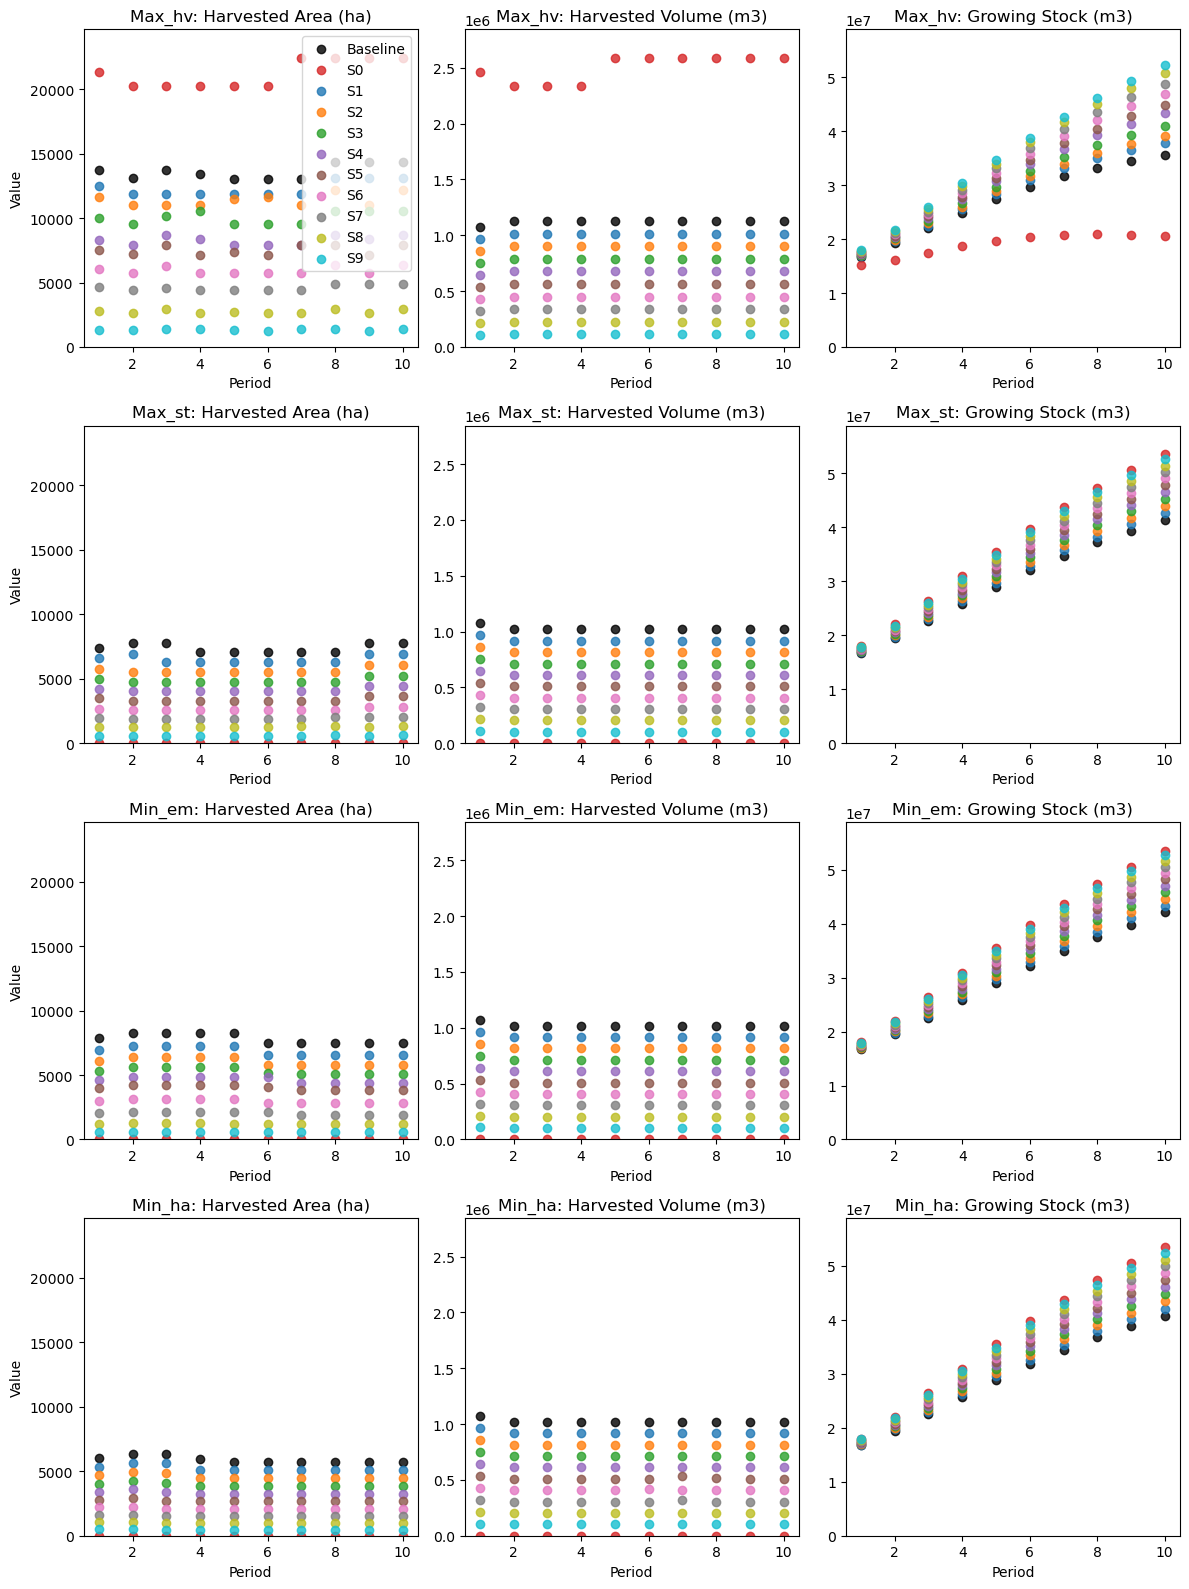

Plot saved to ./plots/fig/redchris/redchris_combined_scheduling_scatterchart.pdf


In [4]:
#Scatter chart for all scenarios Red Chris
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_scenarios(csv_files, case_study, obj_mode):
    """
    Plot data from multiple CSV files into a single figure with shared Y-axis ranges for columns as scatter charts.
    
    Parameters:
        csv_files (list of str): List of CSV file paths to read.
        case_study (str): Case study name for output file naming.
        obj_mode (list of str): List of objective modes corresponding to the CSV files.
    """
    # Initialize figure and axes for subplots
    num_obj_modes = len(obj_mode)
    
    # Create a grid of subplots (num_obj_modes subfigures for each objective mode)
    fig, axes = plt.subplots(num_obj_modes, 3, figsize=(12, 4 * num_obj_modes), squeeze=False)

    # Ensure we have the correct shape for the axes (num_obj_modes rows, 3 columns)
    if axes.shape[0] != num_obj_modes:
        axes = axes.reshape(num_obj_modes, 3)

    # Read data for each scenario and plot
    all_oha, all_ohv, all_ogs = [], [], []
    dfs = []

    # Collect data for plotting
    for file in csv_files:
        try:
            df = pd.read_csv(file)
            # Check required columns exist
            if not all(col in df.columns for col in ['oha', 'ohv', 'ogs', 'period']):
                raise ValueError(f"File {file} does not have required columns: ['oha', 'ohv', 'ogs', 'period']")
            dfs.append(df)
            all_oha.extend(df['oha'])
            all_ohv.extend(df['ohv'])
            all_ogs.extend(df['ogs'])
        except Exception as e:
            print(f"Error reading {file}: {e}")
            return

    # Determine common y-axis ranges
    common_ylim_oha = (0, max(all_oha) * 1.1)
    common_ylim_ohv = (0, max(all_ohv) * 1.1)
    common_ylim_ogs = (0, max(all_ogs) * 1.1)

    # Map scenario names to objective modes
    scenario_map = {
        "Max_hv": [
            "redchris_max_hv_bau_redchrs_compile_scenario.csv",
            "redchris_max_hv_evenflow_cons_compile_scenario.csv",
            "redchris_max_hv_redchrs_AAC_90%_compile_scenario.csv",
            "redchris_max_hv_redchrs_AAC_80%_compile_scenario.csv",
            "redchris_max_hv_redchrs_AAC_70%_compile_scenario.csv",
            "redchris_max_hv_redchrs_AAC_60%_compile_scenario.csv",
            "redchris_max_hv_redchrs_AAC_50%_compile_scenario.csv",
            "redchris_max_hv_redchrs_AAC_40%_compile_scenario.csv",
            "redchris_max_hv_redchrs_AAC_30%_compile_scenario.csv",
            "redchris_max_hv_redchrs_AAC_20%_compile_scenario.csv",
            "redchris_max_hv_redchrs_AAC_10%_compile_scenario.csv"
        ],
        "Max_st": [
            "redchris_max_st_bau_redchrs_compile_scenario_maxstock.csv",
            "redchris_max_st_evenflow_cons_compile_scenario_maxstock.csv",
            "redchris_max_st_redchrs_AAC_90%_compile_scenario_maxstock.csv",
            "redchris_max_st_redchrs_AAC_80%_compile_scenario_maxstock.csv",
            "redchris_max_st_redchrs_AAC_70%_compile_scenario_maxstock.csv",
            "redchris_max_st_redchrs_AAC_60%_compile_scenario_maxstock.csv",
            "redchris_max_st_redchrs_AAC_50%_compile_scenario_maxstock.csv",
            "redchris_max_st_redchrs_AAC_40%_compile_scenario_maxstock.csv",
            "redchris_max_st_redchrs_AAC_30%_compile_scenario_maxstock.csv",
            "redchris_max_st_redchrs_AAC_20%_compile_scenario_maxstock.csv",
            "redchris_max_st_redchrs_AAC_10%_compile_scenario_maxstock.csv"
        ],
        "Min_em": [
            "redchris_min_em_bau_redchrs_compile_scenario_minemission.csv",
            "redchris_min_em_evenflow_cons_compile_scenario_minemission.csv",
            "redchris_min_em_redchrs_AAC_90%_compile_scenario_minemission.csv",
            "redchris_min_em_redchrs_AAC_80%_compile_scenario_minemission.csv",
            "redchris_min_em_redchrs_AAC_70%_compile_scenario_minemission.csv",
            "redchris_min_em_redchrs_AAC_60%_compile_scenario_minemission.csv",
            "redchris_min_em_redchrs_AAC_50%_compile_scenario_minemission.csv",
            "redchris_min_em_redchrs_AAC_40%_compile_scenario_minemission.csv",
            "redchris_min_em_redchrs_AAC_30%_compile_scenario_minemission.csv",
            "redchris_min_em_redchrs_AAC_20%_compile_scenario_minemission.csv",
            "redchris_min_em_redchrs_AAC_10%_compile_scenario_minemission.csv"
        ],
        "Min_ha": [
            "redchris_min_ha_bau_redchrs_compile_scenario.csv",
            "redchris_min_ha_evenflow_cons_compile_scenario.csv",
            "redchris_min_ha_redchrs_AAC_90%_compile_scenario.csv",
            "redchris_min_ha_redchrs_AAC_80%_compile_scenario.csv",
            "redchris_min_ha_redchrs_AAC_70%_compile_scenario.csv",
            "redchris_min_ha_redchrs_AAC_60%_compile_scenario.csv",
            "redchris_min_ha_redchrs_AAC_50%_compile_scenario.csv",
            "redchris_min_ha_redchrs_AAC_40%_compile_scenario.csv",
            "redchris_min_ha_redchrs_AAC_30%_compile_scenario.csv",
            "redchris_min_ha_redchrs_AAC_20%_compile_scenario.csv",
            "redchris_min_ha_redchrs_AAC_10%_compile_scenario.csv"
        ]
    }

    
    scenario_short_labels = {
        # Max_hv scenarios
        "./plots/redchris/redchris_max_hv_bau_redchrs_compile_scenario.csv": 'Baseline',
        "./plots/redchris/redchris_max_hv_evenflow_cons_compile_scenario.csv": 'S0',
        "./plots/redchris/redchris_max_hv_redchrs_AAC_90%_compile_scenario.csv": 'S1',
        "./plots/redchris/redchris_max_hv_redchrs_AAC_80%_compile_scenario.csv": 'S2',
        "./plots/redchris/redchris_max_hv_redchrs_AAC_70%_compile_scenario.csv": 'S3',
        "./plots/redchris/redchris_max_hv_redchrs_AAC_60%_compile_scenario.csv": 'S4',
        "./plots/redchris/redchris_max_hv_redchrs_AAC_50%_compile_scenario.csv": 'S5',
        "./plots/redchris/redchris_max_hv_redchrs_AAC_40%_compile_scenario.csv": 'S6',
        "./plots/redchris/redchris_max_hv_redchrs_AAC_30%_compile_scenario.csv": 'S7',
        "./plots/redchris/redchris_max_hv_redchrs_AAC_20%_compile_scenario.csv": 'S8',
        "./plots/redchris/redchris_max_hv_redchrs_AAC_10%_compile_scenario.csv": 'S9',    
        # Max_st scenarios
        "./plots/redchris/redchris_max_st_bau_redchrs_compile_scenario_maxstock.csv": 'Baseline',
        "./plots/redchris/redchris_max_st_evenflow_cons_compile_scenario_maxstock.csv": 'S0',
        "./plots/redchris/redchris_max_st_redchrs_AAC_90%_compile_scenario_maxstock.csv": 'S1',
        "./plots/redchris/redchris_max_st_redchrs_AAC_80%_compile_scenario_maxstock.csv": 'S2',
        "./plots/redchris/redchris_max_st_redchrs_AAC_70%_compile_scenario_maxstock.csv": 'S3',
        "./plots/redchris/redchris_max_st_redchrs_AAC_60%_compile_scenario_maxstock.csv": 'S4',
        "./plots/redchris/redchris_max_st_redchrs_AAC_50%_compile_scenario_maxstock.csv": 'S5',
        "./plots/redchris/redchris_max_st_redchrs_AAC_40%_compile_scenario_maxstock.csv": 'S6',
        "./plots/redchris/redchris_max_st_redchrs_AAC_30%_compile_scenario_maxstock.csv": 'S7',
        "./plots/redchris/redchris_max_st_redchrs_AAC_20%_compile_scenario_maxstock.csv": 'S8',
        "./plots/redchris/redchris_max_st_redchrs_AAC_10%_compile_scenario_maxstock.csv": 'S9',    
        # Min_em scenarios
        "./plots/redchris/redchris_min_em_bau_redchrs_compile_scenario_minemission.csv": 'Baseline',
        "./plots/redchris/redchris_min_em_evenflow_cons_compile_scenario_minemission.csv": 'S0',
        "./plots/redchris/redchris_min_em_redchrs_AAC_90%_compile_scenario_minemission.csv": 'S1',
        "./plots/redchris/redchris_min_em_redchrs_AAC_80%_compile_scenario_minemission.csv": 'S2',
        "./plots/redchris/redchris_min_em_redchrs_AAC_70%_compile_scenario_minemission.csv": 'S3',
        "./plots/redchris/redchris_min_em_redchrs_AAC_60%_compile_scenario_minemission.csv": 'S4',
        "./plots/redchris/redchris_min_em_redchrs_AAC_50%_compile_scenario_minemission.csv": 'S5',
        "./plots/redchris/redchris_min_em_redchrs_AAC_40%_compile_scenario_minemission.csv": 'S6',
        "./plots/redchris/redchris_min_em_redchrs_AAC_30%_compile_scenario_minemission.csv": 'S7',
        "./plots/redchris/redchris_min_em_redchrs_AAC_20%_compile_scenario_minemission.csv": 'S8',
        "./plots/redchris/redchris_min_em_redchrs_AAC_10%_compile_scenario_minemission.csv": 'S9',
        # Min_ha scenarios
        "./plots/redchris/redchris_min_ha_bau_redchrs_compile_scenario.csv": 'Baseline',
        "./plots/redchris/redchris_min_ha_evenflow_cons_compile_scenario.csv": 'S0',
        "./plots/redchris/redchris_min_ha_redchrs_AAC_90%_compile_scenario.csv": 'S1',
        "./plots/redchris/redchris_min_ha_redchrs_AAC_80%_compile_scenario.csv": 'S2',
        "./plots/redchris/redchris_min_ha_redchrs_AAC_70%_compile_scenario.csv": 'S3',
        "./plots/redchris/redchris_min_ha_redchrs_AAC_60%_compile_scenario.csv": 'S4',
        "./plots/redchris/redchris_min_ha_redchrs_AAC_50%_compile_scenario.csv": 'S5',
        "./plots/redchris/redchris_min_ha_redchrs_AAC_40%_compile_scenario.csv": 'S6',
        "./plots/redchris/redchris_min_ha_redchrs_AAC_30%_compile_scenario.csv": 'S7',
        "./plots/redchris/redchris_min_ha_redchrs_AAC_20%_compile_scenario.csv": 'S8',
        "./plots/redchris/redchris_min_ha_redchrs_AAC_10%_compile_scenario.csv": 'S9',
        }


    color_palette = {
        'Baseline': 'black',
        'S0': mcolors.TABLEAU_COLORS['tab:red'],
        'S1': mcolors.TABLEAU_COLORS['tab:blue'],
        'S2': mcolors.TABLEAU_COLORS['tab:orange'],
        'S3': mcolors.TABLEAU_COLORS['tab:green'],
        'S4': mcolors.TABLEAU_COLORS['tab:purple'],
        'S5': mcolors.TABLEAU_COLORS['tab:brown'],
        'S6': mcolors.TABLEAU_COLORS['tab:pink'],
        'S7': mcolors.TABLEAU_COLORS['tab:gray'],
        'S8': mcolors.TABLEAU_COLORS['tab:olive'],
        'S9': mcolors.TABLEAU_COLORS['tab:cyan']
    }


    # Plot each DataFrame for each objective mode
    for i, obj in enumerate(obj_mode):
        for j, (data, title, ylabel) in enumerate(
            zip(
                ['oha', 'ohv', 'ogs'],
                [f'{obj}: Harvested Area (ha)', f'{obj}: Harvested Volume (m3)', f'{obj}: Growing Stock (m3)'],
                ["Harvested Area (ha)", "Harvested Volume (m3)", "Growing Stock (m3)"]
            )
        ):
            # Filter scenarios for the current objective mode
            filtered_scenarios = scenario_map.get(obj, [])
            for idx, scenario in enumerate(filtered_scenarios):
                # Find the scenario CSV file
                scenario_file = next((file for file in csv_files if scenario in file), None)
                if scenario_file:
                    scenario_data = pd.read_csv(scenario_file)
                    short_label = scenario_short_labels.get(scenario_file, scenario_file)  # Default to full file name if no short label found                 

                    color = color_palette.get(short_label, mcolors.TABLEAU_COLORS['tab:blue'])  # Default color if not found
                    
                    scatter = axes[i, j].scatter(scenario_data['period'], scenario_data[data], label=f'{short_label}', alpha=0.8, color=color)

            # Set the y-axis to the common limit for all columns
            if j == 0:
                axes[i, j].set_ylim(common_ylim_oha)
            elif j == 1:
                axes[i, j].set_ylim(common_ylim_ohv)
            else:
                axes[i, j].set_ylim(common_ylim_ogs)

            axes[i, j].set_title(title)
            axes[i, j].set_xlabel("Period")
            axes[0, 0].legend()

        # Set Y-label only on the first column
        axes[i, 0].set_ylabel("Value")

    # Adjust layout to avoid overlap
    plt.tight_layout()

    # Save the figure
    folder_path = os.path.join('./plots/fig', case_study)
    os.makedirs(folder_path, exist_ok=True)
    file_name = f"{case_study}_combined_scheduling_scatterchart.pdf"
    file_path = os.path.join(folder_path, file_name)
    plt.savefig(file_path, format='pdf')
    plt.show()
    plt.close()
    print(f"Plot saved to {file_path}")

folder_path = './plots/redchris'  # Adjust this to the actual folder path
csv_files = [
    os.path.join(folder_path, "redchris_max_hv_bau_redchrs_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_max_hv_evenflow_cons_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_max_hv_redchrs_AAC_10%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_max_hv_redchrs_AAC_20%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_max_hv_redchrs_AAC_30%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_max_hv_redchrs_AAC_40%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_max_hv_redchrs_AAC_50%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_max_hv_redchrs_AAC_60%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_max_hv_redchrs_AAC_70%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_max_hv_redchrs_AAC_80%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_max_hv_redchrs_AAC_90%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_max_st_bau_redchrs_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "redchris_max_st_evenflow_cons_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "redchris_max_st_redchrs_AAC_10%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "redchris_max_st_redchrs_AAC_20%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "redchris_max_st_redchrs_AAC_30%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "redchris_max_st_redchrs_AAC_40%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "redchris_max_st_redchrs_AAC_50%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "redchris_max_st_redchrs_AAC_60%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "redchris_max_st_redchrs_AAC_70%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "redchris_max_st_redchrs_AAC_80%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "redchris_max_st_redchrs_AAC_90%_compile_scenario_maxstock.csv"),
    os.path.join(folder_path, "redchris_min_em_bau_redchrs_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "redchris_min_em_redchrs_AAC_10%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "redchris_min_em_evenflow_cons_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "redchris_min_em_redchrs_AAC_20%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "redchris_min_em_redchrs_AAC_30%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "redchris_min_em_redchrs_AAC_40%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "redchris_min_em_redchrs_AAC_50%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "redchris_min_em_redchrs_AAC_60%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "redchris_min_em_redchrs_AAC_70%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "redchris_min_em_redchrs_AAC_80%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "redchris_min_em_redchrs_AAC_90%_compile_scenario_minemission.csv"),
    os.path.join(folder_path, "redchris_min_ha_bau_redchrs_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_min_ha_evenflow_cons_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_min_ha_redchrs_AAC_10%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_min_ha_redchrs_AAC_20%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_min_ha_redchrs_AAC_30%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_min_ha_redchrs_AAC_40%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_min_ha_redchrs_AAC_50%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_min_ha_redchrs_AAC_60%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_min_ha_redchrs_AAC_70%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_min_ha_redchrs_AAC_80%_compile_scenario.csv"),
    os.path.join(folder_path, "redchris_min_ha_redchrs_AAC_90%_compile_scenario.csv"),
]
case_study = 'redchris'
obj_mode = ['Max_hv', 'Max_st', 'Min_em', 'Min_ha']


plot_scenarios(csv_files, case_study, obj_mode)
